<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/06_Notebook_F_Nonlinear_Aerodynamic_Moment_Model_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Nonlinear Aerodynamic Moment Model with a Neural Network

## 🎯 Learning Objective

In this notebook, we build and study a simple **nonlinear aerodynamic moment model** using a neural network.

We focus on the relationship
$$
C_m = f(\alpha),
$$
where:

- $\alpha$ is the angle of attack,
- $C_m$ is the pitching-moment coefficient.

The goals are to:

1. generate a simple synthetic but physically interpretable dataset,
2. compare a linear model and a neural network,
3. study training and testing behavior,
4. examine interpolation versus extrapolation,
5. interpret the results from an aerospace engineering perspective.

---

## 🧠 Why this is a good example

A linear model may capture a small-angle trend, but a neural network can represent richer nonlinear behavior:
$$
C_m = f(\alpha; \theta).
$$

This notebook is intended to show how a neural network can serve as a **data-driven nonlinear surrogate model**.



## 🔹 Problem Setup

For a first example, we define a synthetic nonlinear aerodynamic moment curve:

$$
C_m(\alpha) = c_1 \alpha + c_3 \alpha^3 + \epsilon,
$$

where:

- the linear term represents the local slope near small angle of attack,
- the cubic term introduces nonlinearity,
- $\epsilon$ represents noise or uncertainty.

This is a useful first model because:

- the response is approximately linear only in a limited regime,
- nonlinear effects become more important away from the origin,
- data may contain measurement noise or simulation noise.

---

## 🔹 Units and convention

In this notebook:

- $\alpha$ is measured in **degrees** for interpretability in plots,
- the model internally uses the degree values directly,
- $C_m$ is nondimensional.

This is acceptable for an example, but in a more careful production workflow, one would explicitly manage units and normalization.


In [14]:

import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams["figure.figsize"] = (7, 4)



## 🔹 Generate a Synthetic Aerodynamic Dataset

We define a smooth nonlinear moment curve over a moderate angle-of-attack range.

For this example, we use:
$$
C_m(\alpha) = -0.05\,\alpha + 0.002\,\alpha^3 + \epsilon,
$$
with $\alpha$ measured in radians inside the formula for better scaling, even though we will plot the input in degrees.

That is, if $\alpha_{\deg}$ is given in degrees, then:
$$
\alpha_{\text{rad}} = \alpha_{\deg}\frac{\pi}{180}.
$$

This choice keeps the coefficient values numerically reasonable while preserving physical interpretability.


In [15]:

# Angle of attack range in degrees
alpha_deg_all = torch.linspace(-20.0, 20.0, 41).unsqueeze(1)

# Convert to radians for the analytic model
alpha_rad_all = alpha_deg_all * np.pi / 180.0

# Synthetic nonlinear aerodynamic moment model
def true_cm(alpha_rad):
    return -0.8 * alpha_rad + 4.0 * alpha_rad**3

# Add mild noise
noise = 0.01 * torch.randn_like(alpha_rad_all)
Cm_all = true_cm(alpha_rad_all) + noise
Cm_true_all = true_cm(alpha_rad_all)

# Train/test split:
# use most points for training but reserve some for testing
perm = torch.randperm(len(alpha_deg_all))
train_idx = perm[:28]
test_idx = perm[28:]

alpha_deg_train = alpha_deg_all[train_idx]
Cm_train = Cm_all[train_idx]

alpha_deg_test = alpha_deg_all[test_idx]
Cm_test = Cm_all[test_idx]

# Sort for plotting
def sort_xy(x, y):
    idx = torch.argsort(x[:, 0])
    return x[idx], y[idx]

alpha_deg_train, Cm_train = sort_xy(alpha_deg_train, Cm_train)
alpha_deg_test, Cm_test = sort_xy(alpha_deg_test, Cm_test)
alpha_deg_all_sorted, Cm_all_sorted = sort_xy(alpha_deg_all, Cm_all)
_, Cm_true_sorted = sort_xy(alpha_deg_all, Cm_true_all)

print("Training samples:", len(alpha_deg_train))
print("Testing samples :", len(alpha_deg_test))


Training samples: 28
Testing samples : 13


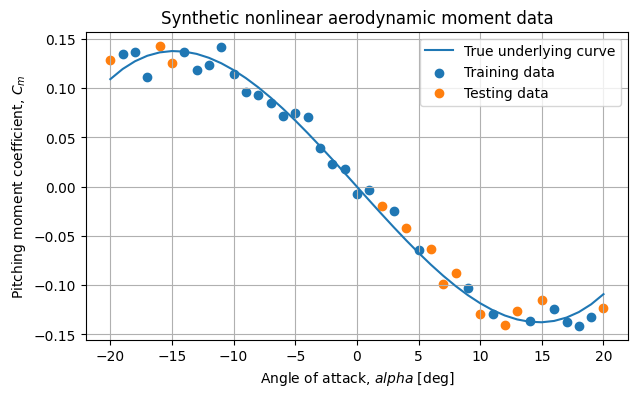

In [16]:

plt.figure()
plt.plot(alpha_deg_all_sorted.numpy(), Cm_true_sorted.numpy(), label="True underlying curve")
plt.scatter(alpha_deg_train.numpy(), Cm_train.numpy(), label="Training data")
plt.scatter(alpha_deg_test.numpy(), Cm_test.numpy(), label="Testing data")
plt.xlabel(r"Angle of attack, $alpha$ [deg]")
plt.ylabel(r"Pitching moment coefficient, $C_m$")
plt.title(r"Synthetic nonlinear aerodynamic moment data")
plt.legend()
plt.grid(True)
plt.show()



## 🔹 Why compare against a linear model?

Before using a neural network, it is useful to ask:

> Is a more flexible model actually needed?

A simple linear model assumes
$$
C_m = a \alpha + b.
$$

In many aerodynamic settings, a linear approximation is valid only over a limited range.  
By comparing a linear regression model to a neural network, we can ask whether the extra flexibility is justified by the data.



## 🔹 Normalize the input

Neural networks usually train more reliably when the input is normalized.

We compute
$$
\alpha_{\text{norm}} = \frac{\alpha - \mu_{\text{train}}}{\sigma_{\text{train}}},
$$
using the **training-set statistics only**.

This is important because test-set information should not leak into preprocessing.


In [17]:

# Normalize alpha using training statistics only
alpha_mean = alpha_deg_train.mean(dim=0, keepdim=True)
alpha_std = alpha_deg_train.std(dim=0, keepdim=True)

alpha_train = (alpha_deg_train - alpha_mean) / alpha_std
alpha_test = (alpha_deg_test - alpha_mean) / alpha_std
alpha_all = (alpha_deg_all_sorted - alpha_mean) / alpha_std

print("Normalized training mean:", alpha_train.mean().item())
print("Normalized training std :", alpha_train.std().item())


Normalized training mean: -4.257474817137563e-09
Normalized training std : 0.9999999403953552



## 🔹 Baseline model: linear regression

We first fit the model
$$
\hat{C}_m = a \alpha_{\text{norm}} + b.
$$

This gives a useful baseline.  
If the linear model already performs well, the neural network may not provide much value.

In engineering practice, a more complex model should earn its place.


In [18]:

class LinearMomentModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

def mse_loss(y_hat, y):
    return torch.mean((y_hat - y) ** 2)

def train_model(model, x_train, y_train, x_test, y_test, lr=0.05, epochs=2000):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = {
        "epoch": [],
        "train_loss": [],
        "test_loss": [],
        "grad_norm": [],
    }

    for epoch in range(epochs):
        model.train()
        y_train_hat = model(x_train)
        train_loss = mse_loss(y_train_hat, y_train)

        optimizer.zero_grad()
        train_loss.backward()

        grad_sq_sum = 0.0
        for p in model.parameters():
            if p.grad is not None:
                grad_sq_sum += torch.sum(p.grad**2).item()
        grad_norm = np.sqrt(grad_sq_sum)

        optimizer.step()

        model.eval()
        with torch.no_grad():
            y_test_hat = model(x_test)
            test_loss = mse_loss(y_test_hat, y_test)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss.item())
        history["test_loss"].append(test_loss.item())
        history["grad_norm"].append(grad_norm)

    return history


In [19]:

torch.manual_seed(1)
linear_model = LinearMomentModel()
hist_linear = train_model(
    linear_model,
    alpha_train, Cm_train,
    alpha_test, Cm_test,
    lr=0.05,
    epochs=2000
)

print("Linear model final training loss:", hist_linear["train_loss"][-1])
print("Linear model final testing loss :", hist_linear["test_loss"][-1])


Linear model final training loss: 0.0004803995543625206
Linear model final testing loss : 0.0009733987390063703



## 🔹 Neural-network model

Now we fit a one-hidden-layer neural network:
$$
z^1 = W^1 \alpha_{\text{norm}} + b^1,
$$
$$
a^1 = \tanh(z^1),
$$
$$
\hat{C}_m = W^2 a^1 + b^2.
$$

The hidden layer allows the model to represent nonlinear structure in the relationship between $\alpha$ and $C_m$.

We use a linear output layer because this is a regression problem.


In [20]:

class NeuralMomentModel(torch.nn.Module):
    def __init__(self, hidden_width=12):
        super().__init__()
        self.fc1 = torch.nn.Linear(1, hidden_width)
        self.fc2 = torch.nn.Linear(hidden_width, 1)

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = torch.tanh(z1)
        y_hat = self.fc2(a1)
        return y_hat


In [21]:

torch.manual_seed(1)
nn_model = NeuralMomentModel(hidden_width=12)
hist_nn = train_model(
    nn_model,
    alpha_train, Cm_train,
    alpha_test, Cm_test,
    lr=0.05,
    epochs=3000
)

print("Neural network final training loss:", hist_nn["train_loss"][-1])
print("Neural network final testing loss :", hist_nn["test_loss"][-1])


Neural network final training loss: 0.0001627117453608662
Neural network final testing loss : 0.00034980004420503974



## 🔹 Compare training histories

The loss curves help us answer:

- Does the neural network fit the data better than the linear model?
- Is the neural network stable during training?
- Is there any obvious sign of overfitting?

A single number is rarely enough.  
The learning history provides more context.


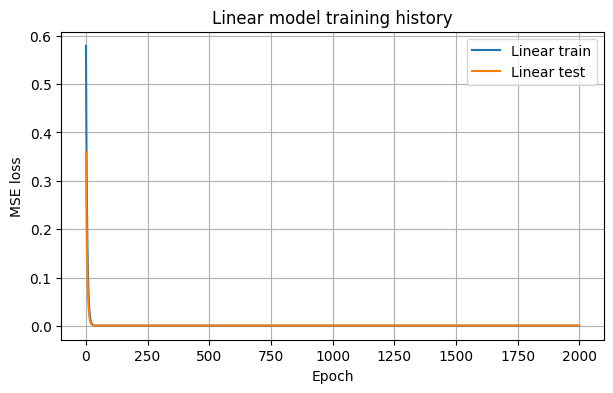

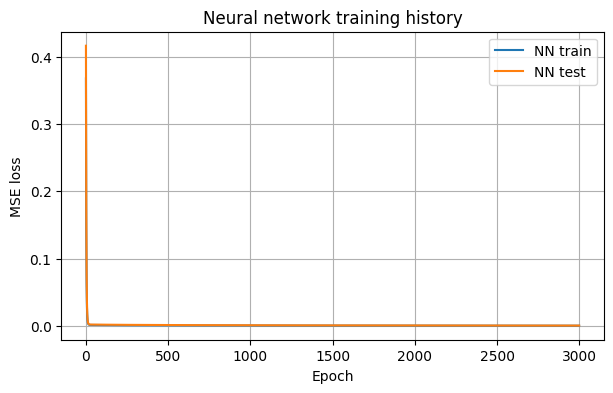

In [22]:

plt.figure()
plt.plot(hist_linear["epoch"], hist_linear["train_loss"], label="Linear train")
plt.plot(hist_linear["epoch"], hist_linear["test_loss"], label="Linear test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Linear model training history")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(hist_nn["epoch"], hist_nn["train_loss"], label="NN train")
plt.plot(hist_nn["epoch"], hist_nn["test_loss"], label="NN test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Neural network training history")
plt.legend()
plt.grid(True)
plt.show()



## 🔹 Compare the learned aerodynamic moment curves

The most important comparison is the learned function itself.

We now compare:

- the true underlying aerodynamic curve,
- the noisy data,
- the linear fit,
- the neural-network fit.

This plot is usually the most informative one for teaching.


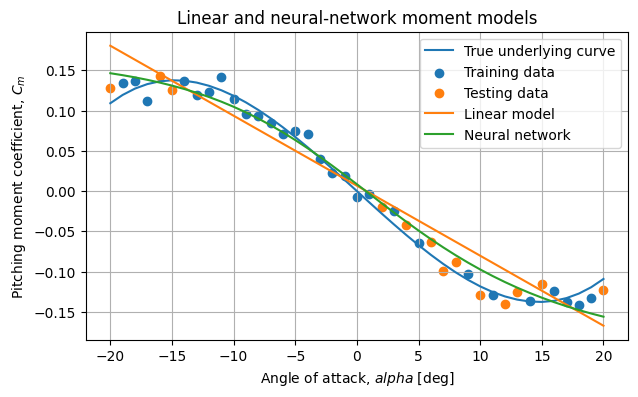

In [23]:

with torch.no_grad():
    Cm_linear_all = linear_model(alpha_all)
    Cm_nn_all = nn_model(alpha_all)

plt.figure()
plt.plot(alpha_deg_all_sorted.numpy(), Cm_true_sorted.numpy(), label="True underlying curve")
plt.scatter(alpha_deg_train.numpy(), Cm_train.numpy(), label="Training data")
plt.scatter(alpha_deg_test.numpy(), Cm_test.numpy(), label="Testing data")
plt.plot(alpha_deg_all_sorted.numpy(), Cm_linear_all.numpy(), label="Linear model")
plt.plot(alpha_deg_all_sorted.numpy(), Cm_nn_all.numpy(), label="Neural network")
plt.xlabel(r"Angle of attack, $alpha$ [deg]")
plt.ylabel(r"Pitching moment coefficient, $C_m$")
plt.title("Linear and neural-network moment models")
plt.legend()
plt.grid(True)
plt.show()



## 🔹 Interpolation versus extrapolation

A model may look good inside the range of training data and still behave poorly outside that range.

This is especially important in aerospace applications, where models are often used at operating conditions that differ from the training conditions.

We therefore test the trained models on an extended range:
$$
\alpha \in [-30^\circ, 30^\circ].
$$

This is a deliberately important lesson:

> Strong interpolation does not guarantee safe extrapolation.


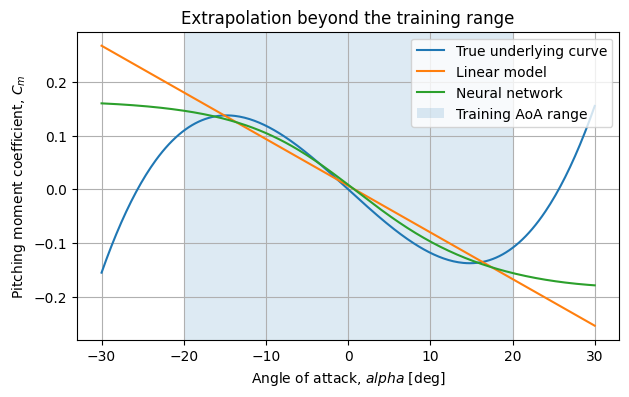

In [24]:

alpha_deg_extra = torch.linspace(-30.0, 30.0, 301).unsqueeze(1)
alpha_rad_extra = alpha_deg_extra * np.pi / 180.0
Cm_true_extra = true_cm(alpha_rad_extra)

alpha_extra = (alpha_deg_extra - alpha_mean) / alpha_std

with torch.no_grad():
    Cm_linear_extra = linear_model(alpha_extra)
    Cm_nn_extra = nn_model(alpha_extra)

plt.figure()
plt.plot(alpha_deg_extra.numpy(), Cm_true_extra.numpy(), label="True underlying curve")
plt.plot(alpha_deg_extra.numpy(), Cm_linear_extra.numpy(), label="Linear model")
plt.plot(alpha_deg_extra.numpy(), Cm_nn_extra.numpy(), label="Neural network")
plt.axvspan(-20, 20, alpha=0.15, label="Training AoA range")
plt.xlabel(r"Angle of attack, $alpha$ [deg]")
plt.ylabel(r"Pitching moment coefficient, $C_m$")
plt.title("Extrapolation beyond the training range")
plt.legend()
plt.grid(True)
plt.show()



## 🔍 Sanity Check

At this point, verify the following:

- Is the neural network training stable?
- Is the neural network test loss lower than the linear-model test loss?
- Does the neural network capture the nonlinear curvature more accurately?
- Do either of the models behave suspiciously outside the training range?
- Is the extrapolation behavior physically trustworthy, or merely numerically smooth?

These questions matter as much as the final loss values.



## 🔹 Quantitative comparison

We summarize the final training and testing losses to complement the plots.

Remember:

- a lower testing loss is usually more meaningful than a lower training loss,
- but even a low testing loss inside the sampled range does not guarantee reliable extrapolation.


In [25]:

summary = {
    "Linear model": {
        "final_train_loss": hist_linear["train_loss"][-1],
        "final_test_loss": hist_linear["test_loss"][-1],
    },
    "Neural network": {
        "final_train_loss": hist_nn["train_loss"][-1],
        "final_test_loss": hist_nn["test_loss"][-1],
    },
}

for model_name, vals in summary.items():
    print(model_name)
    for k, v in vals.items():
        print(f"  {k}: {v:.6e}")


Linear model
  final_train_loss: 4.803996e-04
  final_test_loss: 9.733987e-04
Neural network
  final_train_loss: 1.627117e-04
  final_test_loss: 3.498000e-04



## 🔹 Engineering interpretation

Why is this example meaningful?

In aerodynamic modeling, the pitching moment coefficient may depend on angle of attack in ways that are:

- approximately linear near trim,
- increasingly nonlinear away from trim,
- noisy in measured or simulated data,
- uncertain outside the sampled operating range.

A neural network can be useful because it can represent smooth nonlinear behavior without requiring the analyst to choose an explicit polynomial form in advance.

However, that flexibility comes with responsibility:

- the training data must be representative,
- the model must be validated,
- extrapolation should be treated cautiously,
- physical knowledge should still guide interpretation.

A neural network is a tool for approximation, not a replacement for aerodynamic reasoning.



## 🔹 Optional extension: compare against polynomial regression

The true synthetic model used here is cubic in $\alpha_{\text{rad}}$, so a polynomial model may also work well.

That raises a very good engineering question:

> When is a neural network actually preferable to a simpler parametric surrogate?

A strong modeling workflow should compare:
- simple models,
- flexible models,
- physical insight,
- validation metrics.

In many practical settings, the best model is not the most complicated one.



## 🔹 Reflection Questions

1. Why is the linear model insufficient over the full angle-of-attack range used here?
2. Why does the neural network perform better inside the sampled range?
3. Why should we be cautious about extrapolation even if the network fits the data well?
4. In a real aerodynamic database, what might the noise term represent?
5. What additional inputs could be added to make the model more realistic?

For example, one could extend the model to
$$
C_m = f(\alpha, \dot{\alpha}),
$$
or
$$
C_m = f(\alpha, M, Re),
$$
where $M$ is Mach number and $Re$ is Reynolds number.



## 🧠 Engineering Takeaway

This notebook illustrates a central idea in scientific machine learning:

$$
\hat{C}_m = f(\alpha; \theta)
$$

A neural network can serve as a nonlinear surrogate for an aerodynamic relationship when:
- the data contain nonlinear structure,
- the sampled range is limited but meaningful,
- the model is validated carefully.

But a good engineering model requires more than good optimization.

It requires:
- physical interpretation,
- appropriate baselines,
- careful validation,
- honest treatment of extrapolation risk.



## 🚀 Possible Next Steps

Natural extensions of this notebook include:

1. **Dynamic aerodynamic model**
   $$
   C_m = f(\alpha, \dot{\alpha})
   $$
   to capture rate effects.

2. **Multi-parameter surrogate**
   $$
   C_m = f(\alpha, M, Re)
   $$
   for more realistic aerodynamic databases.

3. **Compare with polynomial regression**
   to discuss when a neural network is or is not justified.

4. **Embed the learned model into a simple pitch-dynamics ODE**
   so the neural network becomes part of a dynamical simulation.

That last direction is especially powerful for connecting neural networks to aerospace dynamics.
